<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


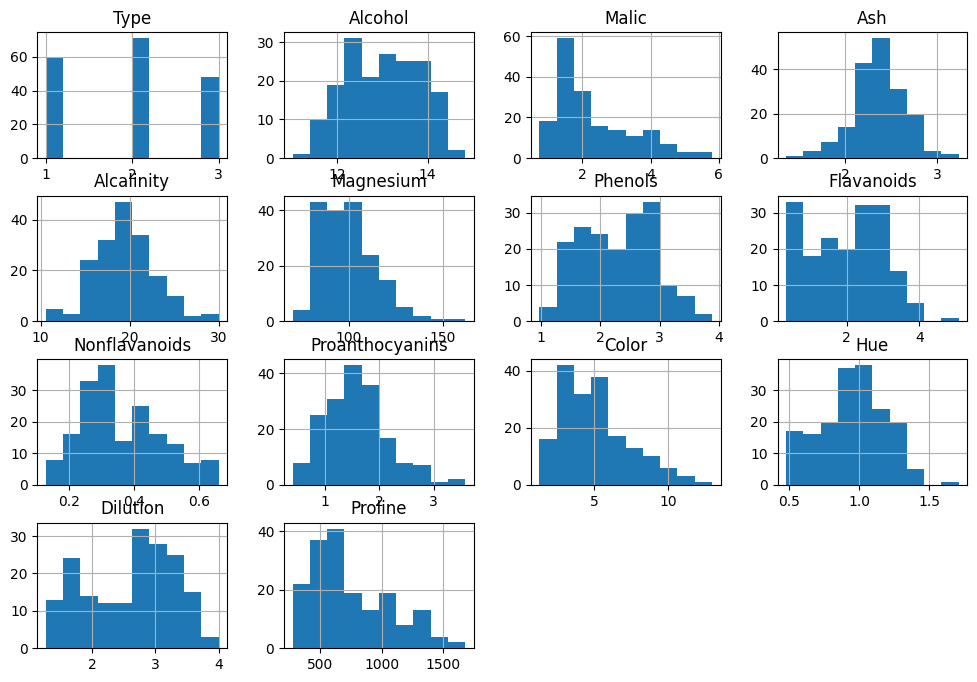

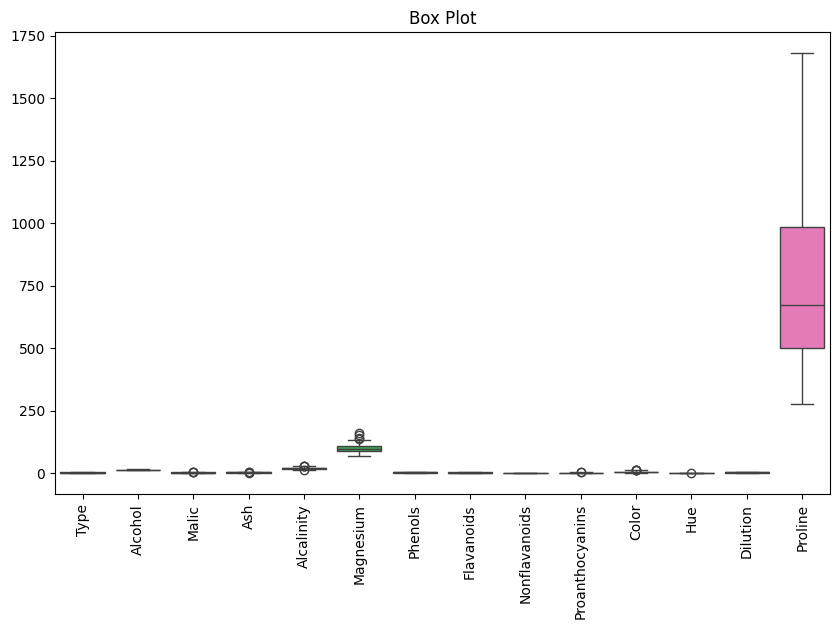

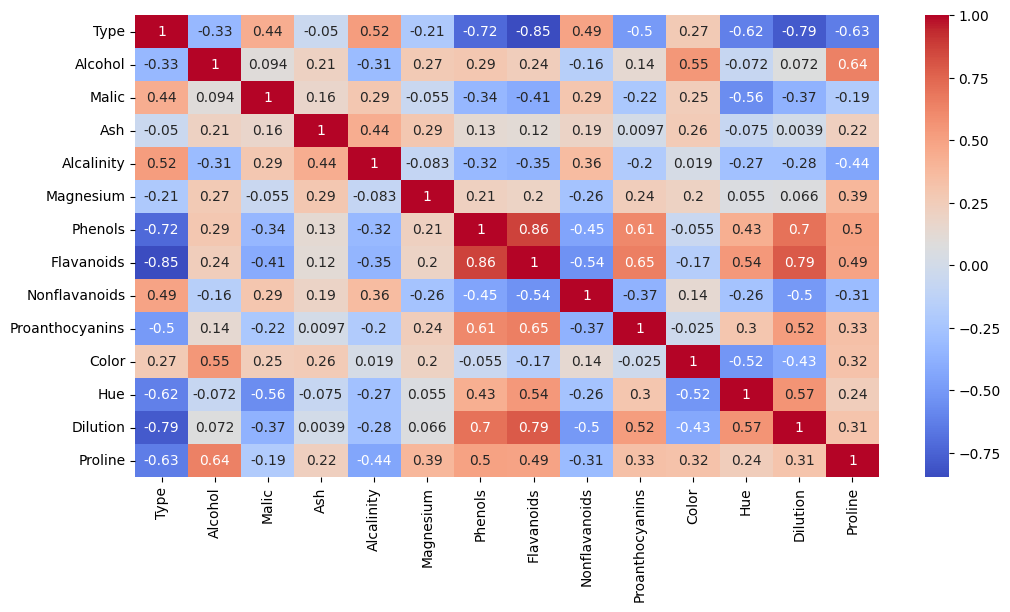

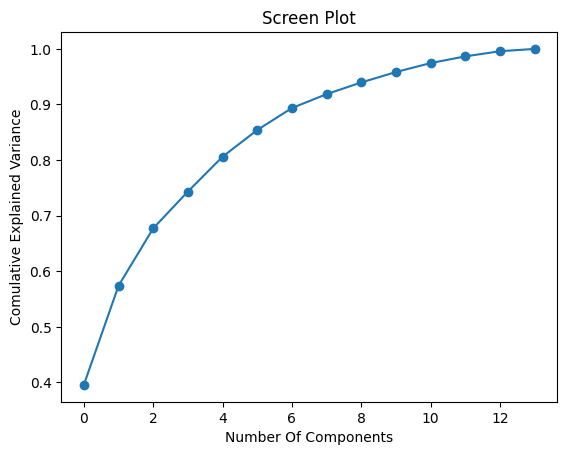

        PC1       PC2
0 -3.522934  1.453098
1 -2.528858 -0.330019
2 -2.785029  1.036936
3 -3.922588  2.768210
4 -1.407511  0.867773


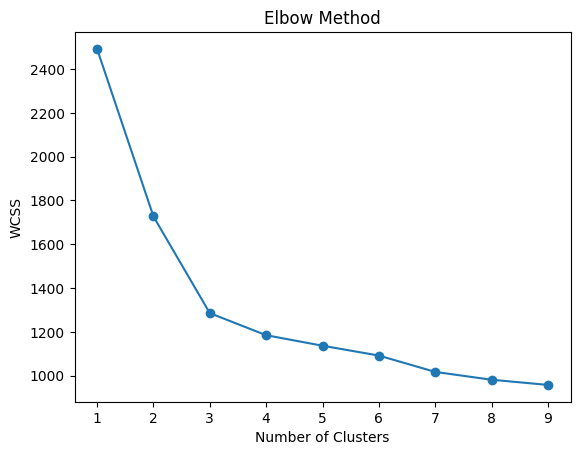

Original Data Silhouette Score: 0.30648398324833453
Original Data DB Index: 1.315707552261773


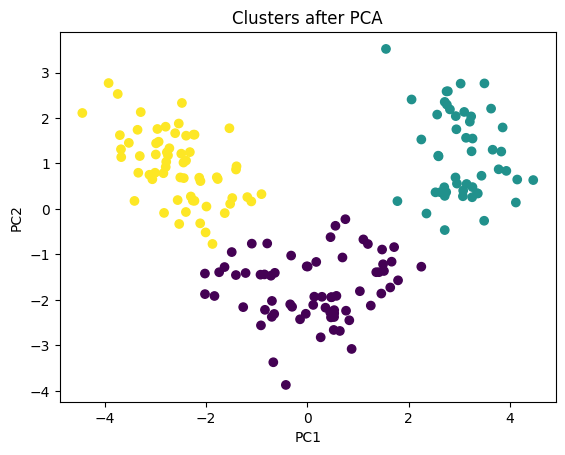

PCA Silhouette Score: 0.6024415520362845
PCA DB Index: 0.5397078562575713

--- COMPARISON ---
Original Silhouette : 0.30648398324833453
PCA Silhouette      : 0.6024415520362845

Original DB Index : 1.315707552261773
PCA DB Index      : 0.5397078562575713


In [2]:
import pandas as pd

df=pd.read_csv(r"/content/wine.csv")

df.info()

df.describe()

df.head()

df.isnull().sum()

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.title("Box Plot")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

from sklearn.decomposition import PCA

pca=PCA()
pca.fit(X_scaled)

import numpy as np

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number Of Components")
plt.ylabel("Comulative Explained Variance")
plt.title("Screen Plot")
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
print(pca_df.head())

from sklearn.cluster import KMeans

wcss = []
for i in range(1,10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans_org = KMeans(n_clusters=3, random_state=42)
labels_org = kmeans_org.fit_predict(X_scaled)

from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Original Data Silhouette Score:", silhouette_score(X_scaled, labels_org))
print("Original Data DB Index:", davies_bouldin_score(X_scaled, labels_org))

kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters after PCA")
plt.show()

print("PCA Silhouette Score:", silhouette_score(X_pca, labels_pca))
print("PCA DB Index:", davies_bouldin_score(X_pca, labels_pca))

print("\n--- COMPARISON ---")
print("Original Silhouette :", silhouette_score(X_scaled, labels_org))
print("PCA Silhouette      :", silhouette_score(X_pca, labels_pca))
print("\nOriginal DB Index :", davies_bouldin_score(X_scaled, labels_org))
print("PCA DB Index      :", davies_bouldin_score(X_pca, labels_pca))



In [1]:
'''
In this assignment, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and analyze its impact on clustering performance using **K-Means clustering.

Initially, clustering was performed on the original dataset.
The results showed that clusters could be identified based on the relationships among features.
However, when PCA was applied, the dataset was transformed into a smaller set of principal components that captured most of the variance in the data.
This helped simplify the dataset while retaining important information.

After applying clustering on the PCA-transformed data, the clustering results were compared with those obtained from the original dataset.
The PCA-based clustering often produced clearer cluster separation and reduced computational complexity because the number of features was smaller.

Key Insights:
PCA effectively reduces dimensionality while preserving important information.
Clustering on PCA-transformed data can improve visualization and computational efficiency.
In some cases, clustering results become more distinct due to reduced noise and redundancy in the data.
However, excessive dimensionality reduction may lead to loss of important information, which can affect clustering accuracy.

Practical Implications:
PCA is particularly useful when working with high-dimensional datasets, as it helps reduce complexity and improve processing speed.
Clustering algorithms such as K-Means often perform better when irrelevant or highly correlated features are reduced.

Recommendation:
It is recommended to apply PCA before clustering when:
The dataset has many correlated features
Visualization of clusters is required
Computational efficiency is important

However, for datasets with few features or when interpretability of original variables is important, clustering directly on the original dataset may be more appropriate.

'''

'\nIn this assignment, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and analyze its impact on clustering performance using **K-Means clustering.\n\nInitially, clustering was performed on the original dataset. \nThe results showed that clusters could be identified based on the relationships among features.\nHowever, when PCA was applied, the dataset was transformed into a smaller set of principal components that captured most of the variance in the data. \nThis helped simplify the dataset while retaining important information.\n\nAfter applying clustering on the PCA-transformed data, the clustering results were compared with those obtained from the original dataset.\nThe PCA-based clustering often produced clearer cluster separation and reduced computational complexity because the number of features was smaller.\n\nKey Insights:\nPCA effectively reduces dimensionality while preserving important information.\nClustering on PCA-transformed dat